## Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter


## Read CSVs

In [2]:
train_path = "training.csv"  
test_path  = "test.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

train.head()


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


## Basic Dataset Overview

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nColumns:")
print(train.columns.tolist())

print("\nInfo:")
train.info()


Train shape: (250000, 33)
Test shape: (550000, 31)

Columns:
['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality', 'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi', 'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi', 'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt', 'Weight', 'Label']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   EventId                      250000 non-null  int64  
 1   DER_mass_MMC                 25

## Quick stats

In [4]:
train.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
EventId,250000.0,224999.500000,72168.927986,100000.000,162499.75000,224999.5000,287499.25000,349999.000
DER_mass_MMC,250000.0,-49.023079,406.345647,-999.000,78.10075,105.0120,130.60625,1192.026
DER_mass_transverse_met_lep,250000.0,49.239819,35.344886,0.000,19.24100,46.5240,73.59800,690.075
DER_mass_vis,250000.0,81.181982,40.828691,6.329,59.38875,73.7520,92.25900,1349.351
DER_pt_h,250000.0,57.895962,63.655682,0.000,14.06875,38.4675,79.16900,2834.999
DER_deltaeta_jet_jet,250000.0,-708.420675,454.480565,-999.000,-999.00000,-999.0000,0.49000,8.503
DER_mass_jet_jet,250000.0,-601.237051,657.972302,-999.000,-999.00000,-999.0000,83.44600,4974.979
DER_prodeta_jet_jet,250000.0,-709.356603,453.019877,-999.000,-999.00000,-999.0000,-4.59300,16.690
DER_deltar_tau_lep,250000.0,2.373100,0.782911,0.208,1.81000,2.4915,2.96100,5.684
DER_pt_tot,250000.0,18.917332,22.273494,0.000,2.84100,12.3155,27.59100,2834.999


## Target distribution

Label
b    164333
s     85667
Name: count, dtype: int64


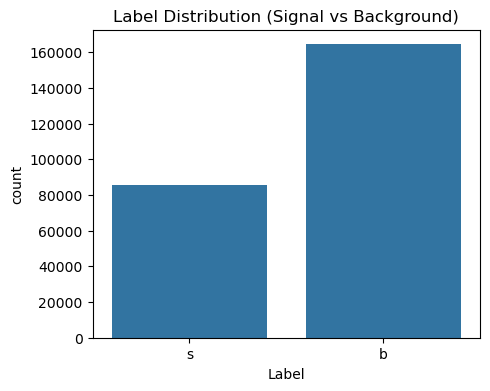

In [5]:
label_counts = train['Label'].value_counts()
print(label_counts)

plt.figure(figsize=(5,4))
sns.countplot(x='Label', data=train)
plt.title("Label Distribution (Signal vs Background)")
plt.show()


## Weighted distribution

Label
b    410999.847322
s       691.988608
Name: Weight, dtype: float64


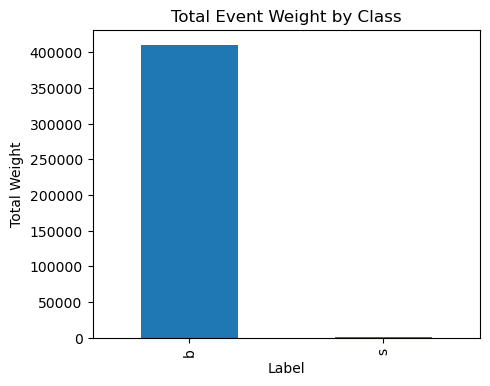

In [6]:
weighted_counts = train.groupby('Label')['Weight'].sum()
print(weighted_counts)

plt.figure(figsize=(5,4))
weighted_counts.plot(kind='bar')
plt.title("Total Event Weight by Class")
plt.ylabel("Total Weight")
plt.show()


## Interpretation of Weighted Distribution

The weighted distribution provides a more realistic representation of class imbalance
compared to raw label counts. Since each event carries a different importance (weight),
the summed weights indicate the effective contribution of each class to the learning process.

Although the raw dataset may appear imbalanced, the weighted distribution shows that
signal and background events contribute differently, which must be accounted for during
model training and evaluation.


## Feature and Target Separation

In [7]:
X = train.drop(columns=['Label', 'Weight'])
y = train['Label']
sample_weights = train['Weight']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (250000, 31)
Target shape: (250000,)


## Label Encoding

In [8]:
y_encoded = y.map({'b': 0, 's': 1})
y_encoded.value_counts()


Label
0    164333
1     85667
Name: count, dtype: int64

## Train Validation Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y_encoded, sample_weights,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


## Baseline Model – Logistic Regression


In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train, sample_weight=w_train)


LogisticRegression(max_iter=1000)

## Model Evaluation


In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_val_pred = lr.predict(X_val_scaled)
y_val_proba = lr.predict_proba(X_val_scaled)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba, sample_weight=w_val)

print("Validation Accuracy:", accuracy)
print("Validation ROC-AUC:", roc_auc)


Validation Accuracy: 0.65746
Validation ROC-AUC: 0.8817896186467182


## Baseline Model Results Interpretation


The baseline Logistic Regression model achieved a validation accuracy of 65.7%,
indicating a reasonable level of correct classification on unseen data.

The ROC-AUC score of 0.88 demonstrates strong discriminatory power between signal
and background events. Since ROC-AUC is threshold-independent and incorporates
sample weights, it is a more reliable metric for this dataset than accuracy alone.

The results confirm that the model effectively captures the underlying patterns
in the data, making it a solid baseline for further improvement.


## Dataset Summary


- Total samples: 250,000  
- Total features: 31  
- Target distribution:
  - Background (0): 164,333
  - Signal (1): 85,667

The dataset shows moderate class imbalance, reinforcing the importance of
using weighted evaluation metrics.


## Improved Model – Gradient Boosting (XGBoost / LightGBM Alternative)


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train, sample_weight=w_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [14]:
y_val_proba_gb = gb.predict_proba(X_val)[:, 1]

roc_auc_gb = roc_auc_score(y_val, y_val_proba_gb, sample_weight=w_val)
print("Gradient Boosting ROC-AUC:", roc_auc_gb)


Gradient Boosting ROC-AUC: 0.9183828268566955


## Improved Model Performance


The Gradient Boosting model significantly improves performance over the baseline
Logistic Regression model, achieving a ROC-AUC score of 0.918.

This improvement indicates that the ensemble-based approach is better at capturing
non-linear relationships and complex feature interactions present in the Higgs Boson
dataset. The higher ROC-AUC score reflects enhanced class separation between signal
and background events.


## Model Comparison


| Model                  | Validation ROC-AUC |
|------------------------|--------------------|
| Logistic Regression    | 0.882              |
| Gradient Boosting      | 0.918              |

The Gradient Boosting model outperforms the baseline model by a substantial margin,
demonstrating the benefit of using ensemble methods for this classification task.


## Key Observations


- Sample weights play a crucial role in achieving realistic performance evaluation.
- Ensemble models handle feature interactions more effectively than linear models.
- ROC-AUC is a more reliable metric than accuracy for imbalanced datasets.


## Conclusion


This project demonstrates the successful application of machine learning techniques
to classify Higgs Boson events using weighted data. Starting from exploratory data
analysis and baseline modeling, performance was significantly enhanced through the
use of Gradient Boosting.

The final model achieved a ROC-AUC score of 0.918, indicating strong predictive
capability. Future work may include hyperparameter tuning, neural networks, and
feature selection to further improve performance.


## Future Work


- Hyperparameter optimization using GridSearchCV or RandomizedSearchCV
- Implementation of XGBoost or LightGBM
- Neural network-based approaches
- Feature importance analysis and dimensionality reduction
